# AI vs. Human Text Classifier
Statistical/feature-based approach using GPT-2 perplexity, burstiness, readability scores, POS ratios, and lexical features.
Data: HC3 + GPT-wiki-intro (HuggingFace). Model: best of LR / RF / XGBoost.

## 0. Setup

In [1]:
# Uncomment on first run
# !pip install -r ../requirements.txt
# !python -m spacy download en_core_web_sm

In [2]:
import os, sys, warnings
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from datasets import load_dataset
import nltk

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Add src/ to path so we can import features.py
sys.path.insert(0, os.path.abspath("../src"))
from features import (
    lexical_features, readability_features,
    pos_features_from_doc, compute_pos_features_batch,
    compute_perplexity, compute_perplexity_batch,
    compute_all_features, _ensure_nltk
)

_ensure_nltk()
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_DIR      = "../data/raw"
PROCESSED_DIR = "../data/processed"
MODEL_DIR     = "../models"
FIGURE_DIR    = "../reports/figures"
for d in [DATA_DIR, PROCESSED_DIR, MODEL_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)
print("Setup complete.")

Setup complete.


## 1. Data Loading

In [3]:
# --- HC3 ---
print("Loading HC3...")
hc3_raw = load_dataset("Hello-SimpleAI/HC3", "all", cache_dir=DATA_DIR, trust_remote_code=True)
hc3_df  = hc3_raw["train"].to_pandas()

hc3_human = hc3_df["human_answers"].explode().dropna()
hc3_human = hc3_human[hc3_human.str.strip().str.len() > 50]
hc3_human = pd.DataFrame({"text": hc3_human.values, "label": 0})

hc3_ai = hc3_df["chatgpt_answers"].explode().dropna()
hc3_ai = hc3_ai[hc3_ai.str.strip().str.len() > 50]
hc3_ai = pd.DataFrame({"text": hc3_ai.values, "label": 1})

print(f"HC3  — human: {len(hc3_human):,}  ai: {len(hc3_ai):,}")

Loading HC3...


HC3  — human: 57,552  ai: 26,839


In [4]:
# --- GPT-wiki-intro ---
print("Loading GPT-wiki-intro...")
wiki_raw = load_dataset("aadityaubhat/GPT-wiki-intro", cache_dir=DATA_DIR)
wiki_df  = wiki_raw["train"].to_pandas()

wiki_human = pd.DataFrame({"text": wiki_df["wiki_intro"].values, "label": 0})
wiki_ai    = pd.DataFrame({"text": wiki_df["generated_intro"].values, "label": 1})

wiki_human = wiki_human[wiki_human["text"].str.strip().str.len() > 50]
wiki_ai    = wiki_ai[wiki_ai["text"].str.strip().str.len() > 50]

# Cap wiki at 5k/class to avoid encyclopedic-style bias
WIKI_CAP = 5_000
wiki_human = wiki_human.sample(min(WIKI_CAP, len(wiki_human)), random_state=RANDOM_STATE)
wiki_ai    = wiki_ai.sample(min(WIKI_CAP, len(wiki_ai)),    random_state=RANDOM_STATE)
print(f"Wiki — human: {len(wiki_human):,}  ai: {len(wiki_ai):,}")

Loading GPT-wiki-intro...


Wiki — human: 5,000  ai: 5,000


In [5]:
from langdetect import detect, LangDetectException

def is_english(text):
    try:
        return detect(text) == "en"
    except LangDetectException:
        return False

# Pool, deduplicate, balance, shuffle
all_human = pd.concat([hc3_human, wiki_human], ignore_index=True).drop_duplicates("text")
all_ai    = pd.concat([hc3_ai,    wiki_ai],    ignore_index=True).drop_duplicates("text")

N_SAMPLES = 20_000
all_human = all_human.sample(min(N_SAMPLES, len(all_human)), random_state=RANDOM_STATE)
all_ai    = all_ai.sample(min(N_SAMPLES, len(all_ai)),    random_state=RANDOM_STATE)

df = pd.concat([all_human, all_ai], ignore_index=True)
df["text"] = df["text"].astype(str).str.strip()

# Filter: ≥3 sentences, English only
print("Filtering short / non-English texts...")
df["sent_count_pre"] = df["text"].apply(lambda t: len(nltk.sent_tokenize(t)))
df = df[df["sent_count_pre"] >= 3].reset_index(drop=True)

print("Detecting language (sample check — may take a moment)...")
en_mask = df["text"].apply(is_english)
df = df[en_mask].reset_index(drop=True)
df = df.drop(columns=["sent_count_pre"])
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df["source"] = df["label"].map({0: "human", 1: "ai"})

print(f"Final dataset: {len(df):,} samples")
print(df["source"].value_counts())

Filtering short / non-English texts...


Detecting language (sample check — may take a moment)...


Final dataset: 34,579 samples
source
ai       19540
human    15039
Name: count, dtype: int64


## 2. Exploratory Data Analysis

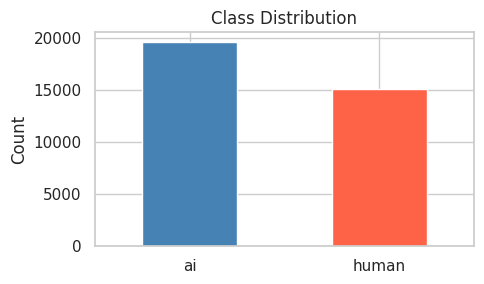

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
df["source"].value_counts().plot.bar(ax=ax, color=["steelblue", "tomato"])
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/class_dist.png", dpi=150)
plt.show()

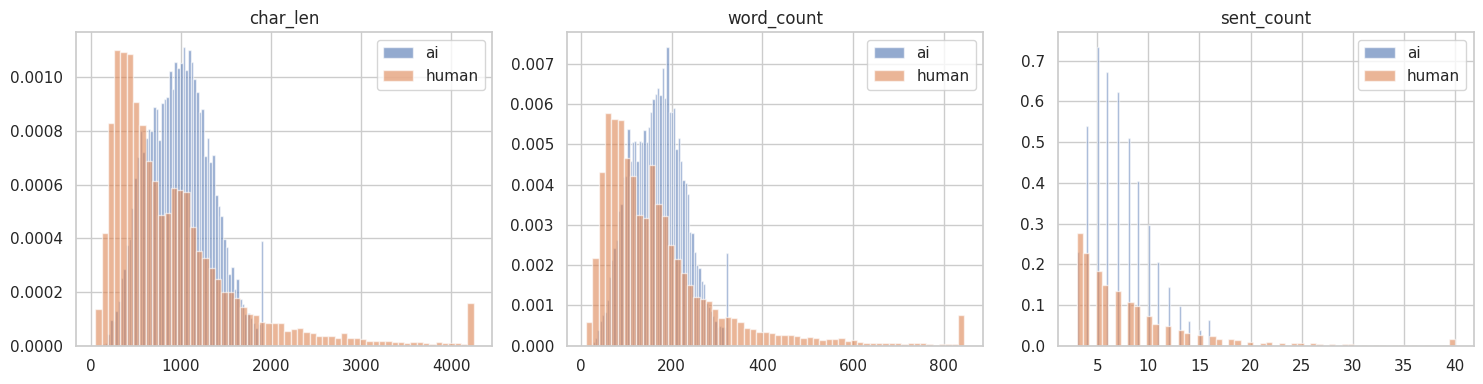

In [7]:
df["char_len"]   = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df["sent_count"] = df["text"].apply(lambda t: len(nltk.sent_tokenize(t)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["char_len", "word_count", "sent_count"]):
    for src, grp in df.groupby("source"):
        cap = grp[col].quantile(0.99)
        grp[col].clip(upper=cap).hist(ax=ax, bins=60, alpha=0.6, label=src, density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/length_dist.png", dpi=150)
plt.show()

In [8]:
pd.set_option("display.max_colwidth", 300)
print("=== Human samples ===")
display(df[df["label"]==0].sample(3, random_state=0)[["text","word_count"]])
print("=== AI samples ===")
display(df[df["label"]==1].sample(3, random_state=0)[["text","word_count"]])

=== Human samples ===


,text,word_count
16098,"Almost all of the calories in regular soda come from the sugar added for sweetening . Diet soft drinks use a zero calorie artificial sweetener called Aspartame instead of sugar or High Fructose Corn Syrup for sweetening . There is some controversy regarding the safety of Aspartame , but most of ...",82
31819,"Water can be used with cobalt to create a cobalt oxide super conductor . Or is you add water to graphite flakes they exhibit some super conductive properties . With water being polar , would n't that cause a lot of issues with all the magnetic fields created by super conductors ? Have a great day !",57
30074,"First , look at the purposes of camouflage on aircraft . In past and present years they had three different goals -- disguise the aircraft on the ground , Disguise the aircraft in the air , or a scheme to make it difficult to judge an aircraft 's distance away , speed , altitude , etc . Green ca...",181


=== AI samples ===


,text,word_count
23723,"Radiation is a type of energy that travels through space and can be found in many different forms, such as radio waves, microwaves, X-rays, and gamma rays. Some types of radiation are harmful to humans and can cause cancer, while other types of radiation can be used to treat cancer.\n\nWhen you ...",204
28569,"Football Manager 2018 is a 2017 football management simulation video game developed by Sports Interactive and published by Sega. The game was released for Microsoft Windows and macOS on 14 November 2017, with a Nintendo Switch release on 6 December 2017.\n\nThe game's updated engine allows for g...",112
29165,"One way to determine if an option is expensive is to compare its price to the underlying stock's price. If the option has a high price relative to the stock price, it may be considered expensive. Another way to determine if an option is expensive is to compare its price to its intrinsic value. T...",256


## 3. Feature Engineering
> **Note:** This section takes ~20–40 min on CPU due to GPT-2 perplexity. A checkpoint is saved to `data/processed/feature_matrix.parquet` after completion. Re-running just loads from disk.

In [9]:
CHECKPOINT = f"{PROCESSED_DIR}/feature_matrix.parquet"

if os.path.exists(CHECKPOINT):
    print(f"Loading checkpoint: {CHECKPOINT}")
    feature_df = pd.read_parquet(CHECKPOINT)
    print(f"Loaded: {feature_df.shape}")
else:
    print("Computing features from scratch...")

    print("  Lexical features...")
    lexical_list = [lexical_features(t) for t in tqdm(df["text"], desc="Lexical")]
    lexical_df = pd.DataFrame(lexical_list)

    print("  Readability features...")
    read_list = [readability_features(t) for t in tqdm(df["text"], desc="Readability")]
    read_df = pd.DataFrame(read_list)

    print("  POS features (spaCy batched)...")
    pos_list = compute_pos_features_batch(df["text"].tolist())
    pos_df = pd.DataFrame(pos_list)

    print("  GPT-2 perplexity (slow step)...")
    ppls = compute_perplexity_batch(df["text"].tolist(), batch_size=16)

    feature_df = pd.concat(
        [lexical_df.reset_index(drop=True),
         read_df.reset_index(drop=True),
         pos_df.reset_index(drop=True)],
        axis=1
    )
    feature_df["gpt2_perplexity"] = ppls
    feature_df["label"] = df["label"].values

    # Fill NaNs with column median
    for col in feature_df.columns:
        if feature_df[col].isnull().any():
            feature_df[col] = feature_df[col].fillna(feature_df[col].median())

    feature_df.to_parquet(CHECKPOINT, index=False)
    print(f"Saved checkpoint: {feature_df.shape}")

Loading checkpoint: ../data/processed/feature_matrix.parquet
Loaded: (34579, 40)


In [10]:
feature_cols = [c for c in feature_df.columns if c != "label"]
print(f"Total features: {len(feature_cols)}")
print(f"NaN counts:\n{feature_df.isnull().sum()[feature_df.isnull().sum() > 0]}")
feature_df.head(3)

Total features: 39
NaN counts:
Series([], dtype: int64)


,char_count,word_count,sent_count,avg_word_length,avg_sent_length,std_sent_length,max_sent_length,burstiness,type_token_ratio,stopword_ratio,...,pos_verb_ratio,pos_adj_ratio,pos_adv_ratio,pos_pron_ratio,pos_det_ratio,pos_conj_ratio,pos_num_ratio,pos_punct_ratio,gpt2_perplexity,label
0,1658,269,20,4.691450,16.400000,9.697422,32.0,0.591306,0.483271,0.446097,...,0.079268,0.079268,0.057927,0.036585,0.146341,0.0,0.033537,0.137195,17.629389,0
1,1460,275,19,4.181818,14.473684,5.725000,30.0,0.395545,0.352727,0.556364,...,0.086817,0.096463,0.045016,0.080386,0.099678,0.0,0.003215,0.115756,5.896036,1
2,1754,311,7,4.363344,45.142857,22.395335,87.0,0.496099,0.308682,0.524116,...,0.124646,0.062323,0.036827,0.065156,0.116147,0.0,0.002833,0.076487,6.303122,1


## 4. Feature Analysis

In [11]:
corr = feature_df[feature_cols].corrwith(feature_df["label"]).abs().sort_values(ascending=False)
print("Top 20 features by |correlation with label|:")
display(corr.head(20).to_frame("abs_corr").style.bar(color="steelblue"))

Top 20 features by |correlation with label|:


,abs_corr
automated_readability,0.502801
type_token_ratio,0.493219
gpt2_perplexity,0.421790
pos_adv_ratio,0.367112
smog_index,0.314497
flesch_kincaid_grade,0.313913
burstiness,0.304820
coleman_liau_index,0.296979
gunning_fog,0.293027
paragraph_count,0.290265


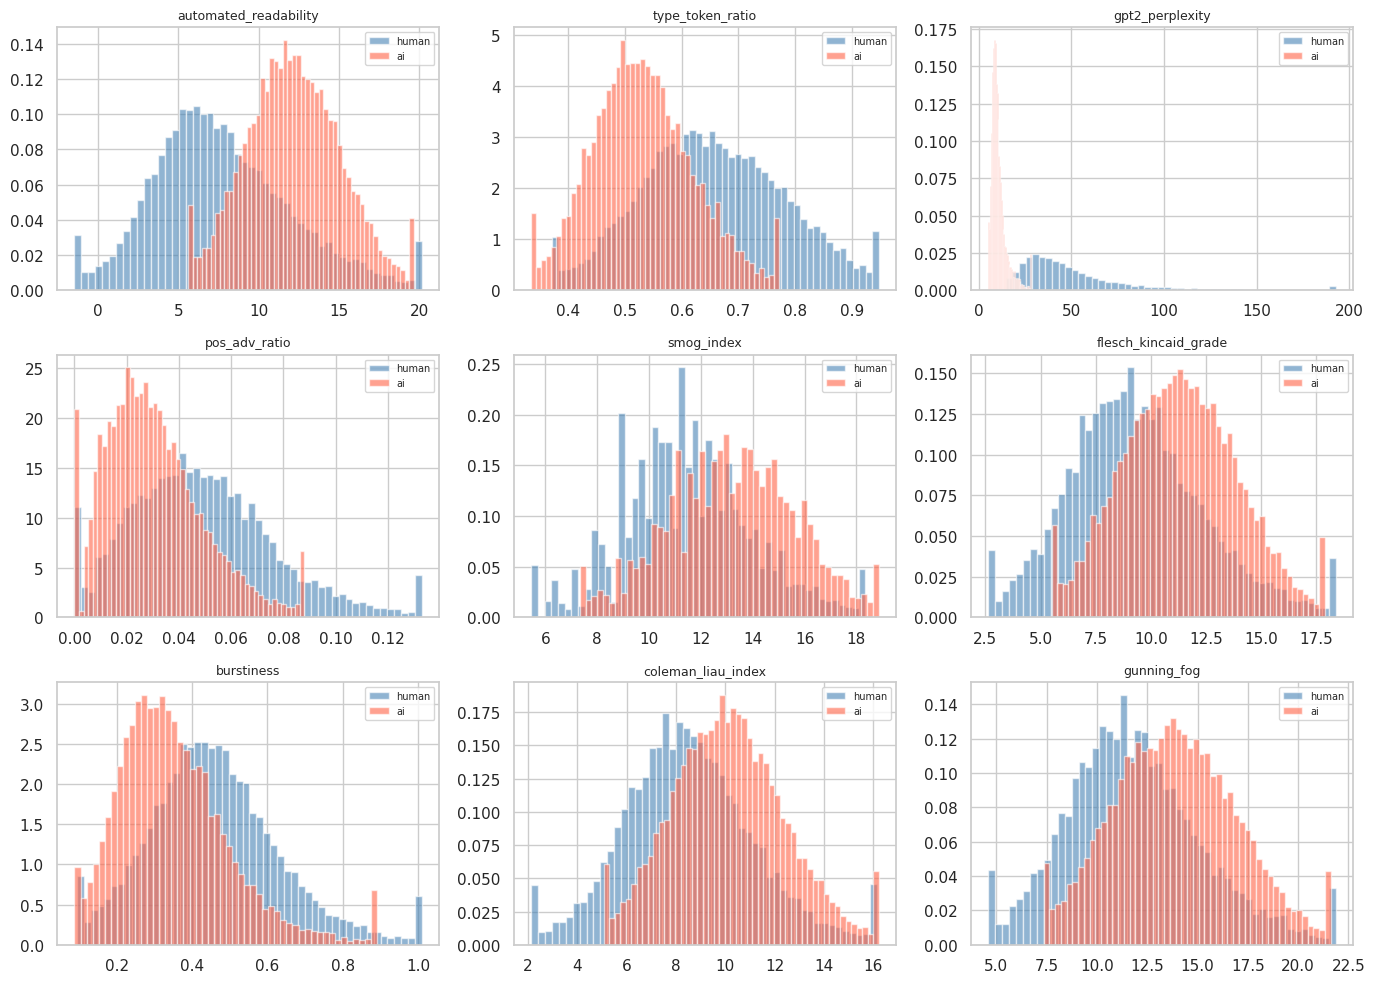

In [12]:
top9 = corr.head(9).index.tolist()
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, feat in zip(axes.flat, top9):
    for label_val, src in [(0, "human"), (1, "ai")]:
        vals = feature_df.loc[feature_df["label"]==label_val, feat]
        vals = vals.clip(lower=vals.quantile(0.01), upper=vals.quantile(0.99))
        vals.hist(ax=ax, bins=50, alpha=0.6, label=src, density=True,
                  color="steelblue" if src=="human" else "tomato")
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/feature_distributions.png", dpi=150)
plt.show()

## 5. Train / Val / Test Split (60 / 20 / 20)

In [13]:
X = feature_df[feature_cols].values
y = feature_df["label"].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE)

print(f"Train : {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}")
print(f"Train class balance: {np.bincount(y_train)}")

Train : 20,747  Val: 6,916  Test: 6,916
Train class balance: [ 9023 11724]


## 6. Model Training

In [14]:
pipelines = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, C=1.0,
                                    class_weight="balanced",
                                    random_state=RANDOM_STATE))
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                        class_weight="balanced",
                                        random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(n_estimators=300, max_depth=6,
                               learning_rate=0.05, subsample=0.8,
                               colsample_bytree=0.8,
                               eval_metric="logloss",
                               random_state=RANDOM_STATE, n_jobs=-1))
    ]),
}

trained = {}
for name, pipe in pipelines.items():
    print(f"Training {name}...")
    if name == "XGBoost":
        # Scale val set manually just to pass as eval_set
        scaler_temp = pipe.named_steps["scaler"]
        pipe.fit(X_train, y_train,
                 clf__eval_set=[(scaler_temp.fit_transform(X_val), y_val)],
                 clf__verbose=False)
    else:
        pipe.fit(X_train, y_train)
    trained[name] = pipe
    val_acc = accuracy_score(y_val, pipe.predict(X_val))
    val_f1  = f1_score(y_val, pipe.predict(X_val), average="macro")
    print(f"  val accuracy={val_acc:.4f}  val F1-macro={val_f1:.4f}")

Training LogisticRegression...


  val accuracy=0.9618  val F1-macro=0.9611
Training RandomForest...


  val accuracy=0.9800  val F1-macro=0.9797
Training XGBoost...


  val accuracy=0.9881  val F1-macro=0.9879


## 7. Cross-Validation on Best Model

In [15]:
best_name = max(trained, key=lambda n: f1_score(y_val, trained[n].predict(X_val), average="macro"))
print(f"Best model (by val F1-macro): {best_name}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(trained[best_name], X_trainval, y_trainval,
                             cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"5-fold CV F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Best model (by val F1-macro): XGBoost


5-fold CV F1-macro: 0.9894 ± 0.0014


## 8. Evaluation on Test Set

In [16]:
results = []
for name, pipe in trained.items():
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    results.append({
        "model":    name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "f1_ai":    f1_score(y_test, y_pred, pos_label=1, average="binary"),
        "f1_human": f1_score(y_test, y_pred, pos_label=0, average="binary"),
        "roc_auc":  roc_auc_score(y_test, y_proba),
    })

results_df = (pd.DataFrame(results)
               .set_index("model")
               .sort_values("f1_macro", ascending=False))
display(results_df.style.highlight_max(axis=0, color="lightgreen").format("{:.4f}"))

,accuracy,f1_macro,f1_ai,f1_human,roc_auc
model,,,,,
XGBoost,0.9894,0.9893,0.9907,0.9879,0.9995
RandomForest,0.9824,0.9821,0.9843,0.9798,0.9988
LogisticRegression,0.9640,0.9632,0.9685,0.9579,0.9925


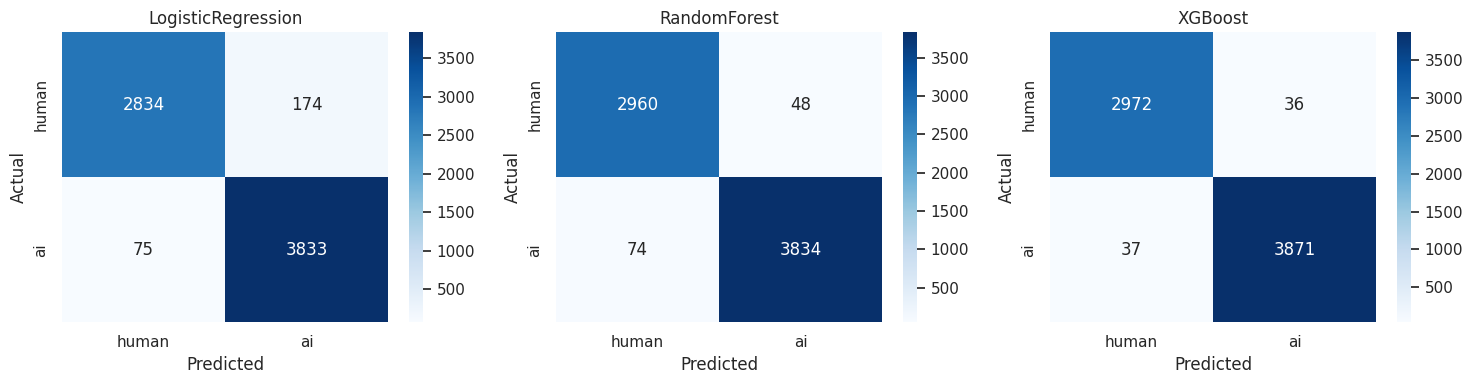

In [17]:
fig, axes = plt.subplots(1, len(trained), figsize=(5 * len(trained), 4))
if len(trained) == 1:
    axes = [axes]
for ax, (name, pipe) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=["human","ai"], yticklabels=["human","ai"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/confusion_matrices.png", dpi=150)
plt.show()

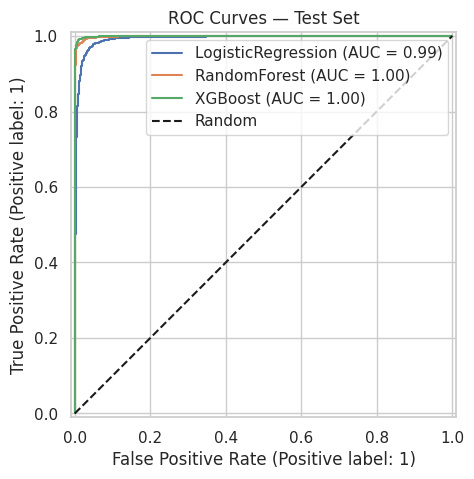

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, pipe in trained.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0,1],[0,1],"k--", label="Random")
ax.set_title("ROC Curves — Test Set")
ax.legend()
plt.savefig(f"{FIGURE_DIR}/roc_curves.png", dpi=150)
plt.show()

In [19]:
print(f"=== Classification Report: {best_name} ===")
print(classification_report(y_test, trained[best_name].predict(X_test),
                             target_names=["human", "ai"]))

=== Classification Report: XGBoost ===
              precision    recall  f1-score   support

       human       0.99      0.99      0.99      3008
          ai       0.99      0.99      0.99      3908

    accuracy                           0.99      6916
   macro avg       0.99      0.99      0.99      6916
weighted avg       0.99      0.99      0.99      6916



## 9. Feature Importance

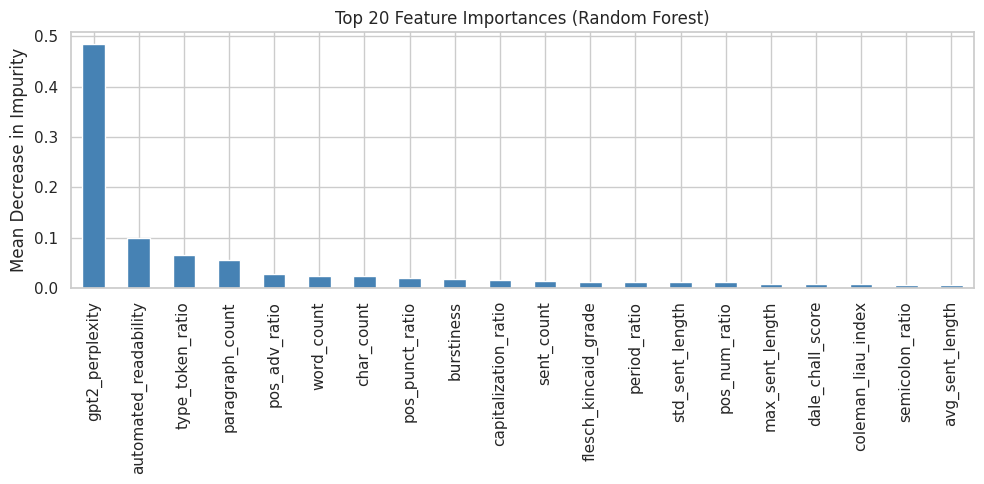

In [20]:
if "RandomForest" in trained:
    rf_clf = trained["RandomForest"].named_steps["clf"]
    rf_imp = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    rf_imp.head(20).plot.bar(ax=ax, color="steelblue")
    ax.set_title("Top 20 Feature Importances (Random Forest)")
    ax.set_ylabel("Mean Decrease in Impurity")
    plt.tight_layout()
    plt.savefig(f"{FIGURE_DIR}/rf_feature_importance.png", dpi=150)
    plt.show()

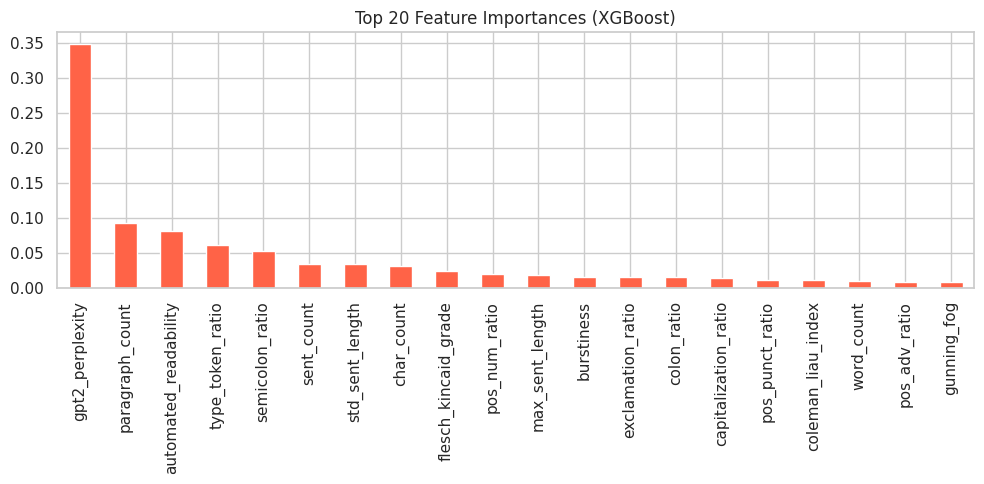

In [21]:
if "XGBoost" in trained:
    xgb_clf = trained["XGBoost"].named_steps["clf"]
    xgb_imp = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    xgb_imp.head(20).plot.bar(ax=ax, color="tomato")
    ax.set_title("Top 20 Feature Importances (XGBoost)")
    plt.tight_layout()
    plt.savefig(f"{FIGURE_DIR}/xgb_feature_importance.png", dpi=150)
    plt.show()

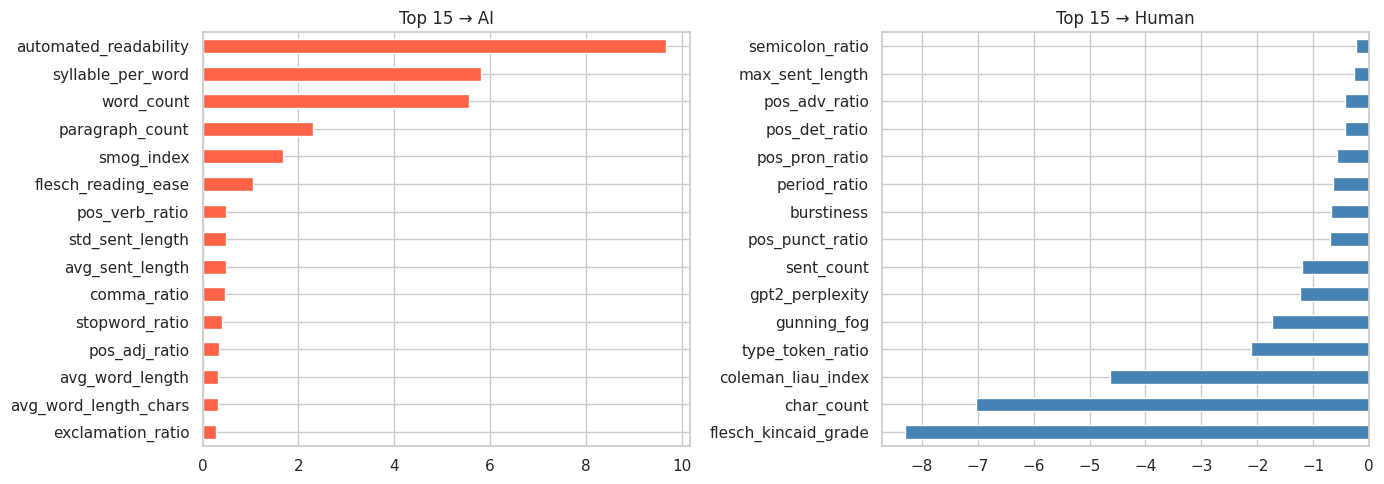

In [22]:
if "LogisticRegression" in trained:
    lr_clf  = trained["LogisticRegression"].named_steps["clf"]
    lr_coef = pd.Series(lr_clf.coef_[0], index=feature_cols).sort_values()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    lr_coef.tail(15).plot.barh(ax=axes[0], color="tomato",   title="Top 15 → AI")
    lr_coef.head(15).plot.barh(ax=axes[1], color="steelblue", title="Top 15 → Human")
    plt.tight_layout()
    plt.savefig(f"{FIGURE_DIR}/lr_coefficients.png", dpi=150)
    plt.show()

## 10. Model Serialization

In [23]:
best_pipe = trained[best_name]

model_path    = f"{MODEL_DIR}/best_model.joblib"
metadata_path = f"{MODEL_DIR}/model_metadata.joblib"

joblib.dump(best_pipe, model_path)

metadata = {
    "model_name":    best_name,
    "feature_cols":  feature_cols,
    "label_map":     {0: "human", 1: "ai"},
    "val_f1_macro":  float(f1_score(y_val,  best_pipe.predict(X_val),  average="macro")),
    "test_f1_macro": float(f1_score(y_test, best_pipe.predict(X_test), average="macro")),
}
joblib.dump(metadata, metadata_path)

print(f"Saved: {model_path}")
print(metadata)

Saved: ../models/best_model.joblib
{'model_name': 'XGBoost', 'feature_cols': ['char_count', 'word_count', 'sent_count', 'avg_word_length', 'avg_sent_length', 'std_sent_length', 'max_sent_length', 'burstiness', 'type_token_ratio', 'stopword_ratio', 'avg_word_length_chars', 'comma_ratio', 'period_ratio', 'exclamation_ratio', 'question_ratio', 'semicolon_ratio', 'colon_ratio', 'quote_ratio', 'capitalization_ratio', 'paragraph_count', 'flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'smog_index', 'coleman_liau_index', 'automated_readability', 'dale_chall_score', 'difficult_words_ratio', 'syllable_per_word', 'pos_noun_ratio', 'pos_verb_ratio', 'pos_adj_ratio', 'pos_adv_ratio', 'pos_pron_ratio', 'pos_det_ratio', 'pos_conj_ratio', 'pos_num_ratio', 'pos_punct_ratio', 'gpt2_perplexity'], 'label_map': {0: 'human', 1: 'ai'}, 'val_f1_macro': 0.987945600545508, 'test_f1_macro': 0.9892633486418466}


In [24]:
# Round-trip verification
loaded      = joblib.load(model_path)
loaded_meta = joblib.load(metadata_path)
np.testing.assert_array_equal(loaded.predict(X_test[:20]), best_pipe.predict(X_test[:20]))
print("Round-trip verification passed.")
print(f"Model expects {len(loaded_meta['feature_cols'])} features.")

Round-trip verification passed.
Model expects 39 features.


In [25]:
# Inference example — template for the future UI
def predict_text(text: str, model=loaded, meta=loaded_meta) -> dict:
    """Predict whether a text is AI-generated or human-written."""
    all_feats = compute_all_features(text)
    X_new = np.array([[all_feats[col] for col in meta["feature_cols"]]])
    pred  = model.predict(X_new)[0]
    proba = model.predict_proba(X_new)[0][pred]
    return {
        "label":       meta["label_map"][pred],
        "probability": float(proba),
        "confidence":  "high" if proba > 0.80 else "medium" if proba > 0.60 else "low",
    }

# Quick smoke test on two samples
sample_ai    = df[df["label"]==1].iloc[0]["text"]
sample_human = df[df["label"]==0].iloc[0]["text"]

print("AI sample:",    predict_text(sample_ai))
print("Human sample:", predict_text(sample_human))

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


AI sample: {'label': 'ai', 'probability': 0.9978280663490295, 'confidence': 'high'}
Human sample: {'label': 'human', 'probability': 0.9979058504104614, 'confidence': 'high'}


In [15]:
import sys
from pathlib import Path

PROJECT_DIR = Path("/home/zoom/notebooks/AI-Text-Classifier")
sys.path.insert(0, str(PROJECT_DIR))

import joblib
import numpy as np
from src.features import compute_all_features

model = joblib.load(PROJECT_DIR / "models/best_model.joblib")
meta = joblib.load(PROJECT_DIR / "models/model_metadata.joblib")

text = """
Article. I.
Section. 1.
All legislative Powers herein granted shall be vested in a Congress of the United States, which shall consist of a Senate and House of Representatives.

Section. 2.
The House of Representatives shall be composed of Members chosen every second Year by the People of the several States, and the Electors in each State shall have the Qualifications requisite for Electors of the most numerous Branch of the State Legislature.

No Person shall be a Representative who shall not have attained to the Age of twenty five Years, and been seven Years a Citizen of the United States, and who shall not, when elected, be an Inhabitant of that State in which he shall be chosen.

Representatives and direct Taxes shall be apportioned among the several States which may be included within this Union, according to their respective Numbers, which shall be determined by adding to the whole Number of free Persons, including those bound to Service for a Term of Years, and excluding Indians not taxed, three fifths of all other Persons. The actual Enumeration shall be made within three Years after the first Meeting of the Congress of the United States, and within every subsequent Term of ten Years, in such Manner as they shall by Law direct. The Number of Representatives shall not exceed one for every thirty Thousand, but each State shall have at Least one Representative; and until such enumeration shall be made, the State of New Hampshire shall be entitled to chuse three, Massachusetts eight, Rhode-Island and Providence Plantations one, Connecticut five, New-York six, New Jersey four, Pennsylvania eight, Delaware one, Maryland six, Virginia ten, North Carolina five, South Carolina five, and Georgia three.

When vacancies happen in the Representation from any State, the Executive Authority thereof shall issue Writs of Election to fill such Vacancies.

The House of Representatives shall chuse their Speaker and other Officers; and shall have the sole Power of Impeachment.

Section. 3.
The Senate of the United States shall be composed of two Senators from each State, chosen by the Legislature thereof, for six Years; and each Senator shall have one Vote.

Immediately after they shall be assembled in Consequence of the first Election, they shall be divided as equally as may be into three Classes. The Seats of the Senators of the first Class shall be vacated at the Expiration of the second Year, of the second Class at the Expiration of the fourth Year, and of the third Class at the Expiration of the sixth Year, so that one third may be chosen every second Year; and if Vacancies happen by Resignation, or otherwise, during the Recess of the Legislature of any State, the Executive thereof may make temporary Appointments until the next Meeting of the Legislature, which shall then fill such Vacancies.

No Person shall be a Senator who shall not have attained to the Age of thirty Years, and been nine Years a Citizen of the United States, and who shall not, when elected, be an Inhabitant of that State for which he shall be chosen.

The Vice President of the United States shall be President of the Senate, but shall have no Vote, unless they be equally divided.

The Senate shall chuse their other Officers, and also a President pro tempore, in the Absence of the Vice President, or when he shall exercise the Office of President of the United States.

The Senate shall have the sole Power to try all Impeachments. When sitting for that Purpose, they shall be on Oath or Affirmation. When the President of the United States is tried, the Chief Justice shall preside: And no Person shall be convicted without the Concurrence of two thirds of the Members present.

Judgment in Cases of Impeachment shall not extend further than to removal from Office, and disqualification to hold and enjoy any Office of honor, Trust or Profit under the United States: but the Party convicted shall nevertheless be liable and subject to Indictment, Trial, Judgment and Punishment, according to Law.

Section. 4.
The Times, Places and Manner of holding Elections for Senators and Representatives, shall be prescribed in each State by the Legislature thereof; but the Congress may at any time by Law make or alter such Regulations, except as to the Places of chusing Senators.

The Congress shall assemble at least once in every Year, and such Meeting shall be on the first Monday in December, unless they shall by Law appoint a different Day.

Section. 5.
Each House shall be the Judge of the Elections, Returns and Qualifications of its own Members, and a Majority of each shall constitute a Quorum to do Business; but a smaller Number may adjourn from day to day, and may be authorized to compel the Attendance of absent Members, in such Manner, and under such Penalties as each House may provide.

Each House may determine the Rules of its Proceedings, punish its Members for disorderly Behaviour, and, with the Concurrence of two thirds, expel a Member.

Each House shall keep a Journal of its Proceedings, and from time to time publish the same, excepting such Parts as may in their Judgment require Secrecy; and the Yeas and Nays of the Members of either House on any question shall, at the Desire of one fifth of those Present, be entered on the Journal.

Neither House, during the Session of Congress, shall, without the Consent of the other, adjourn for more than three days, nor to any other Place than that in which the two Houses shall be sitting.

Section. 6.
The Senators and Representatives shall receive a Compensation for their Services, to be ascertained by Law, and paid out of the Treasury of the United States. They shall in all Cases, except Treason, Felony and Breach of the Peace, be privileged from Arrest during their Attendance at the Session of their respective Houses, and in going to and returning from the same; and for any Speech or Debate in either House, they shall not be questioned in any other Place.

No Senator or Representative shall, during the Time for which he was elected, be appointed to any civil Office under the Authority of the United States, which shall have been created, or the Emoluments whereof shall have been encreased during such time; and no Person holding any Office under the United States, shall be a Member of either House during his Continuance in Office.

Section. 7.
All Bills for raising Revenue shall originate in the House of Representatives; but the Senate may propose or concur with Amendments as on other Bills.

Every Bill which shall have passed the House of Representatives and the Senate, shall, before it become a Law, be presented to the President of the United States; If he approve he shall sign it, but if not he shall return it, with his Objections to that House in which it shall have originated, who shall enter the Objections at large on their Journal, and proceed to reconsider it. If after such Reconsideration two thirds of that House shall agree to pass the Bill, it shall be sent, together with the Objections, to the other House, by which it shall likewise be reconsidered, and if approved by two thirds of that House, it shall become a Law. But in all such Cases the Votes of both Houses shall be determined by yeas and Nays, and the Names of the Persons voting for and against the Bill shall be entered on the Journal of each House respectively. If any Bill shall not be returned by the President within ten Days (Sundays excepted) after it shall have been presented to him, the Same shall be a Law, in like Manner as if he had signed it, unless the Congress by their Adjournment prevent its Return, in which Case it shall not be a Law.

Every Order, Resolution, or Vote to which the Concurrence of the Senate and House of Representatives may be necessary (except on a question of Adjournment) shall be presented to the President of the United States; and before the Same shall take Effect, shall be approved by him, or being disapproved by him, shall be repassed by two thirds of the Senate and House of Representatives, according to the Rules and Limitations prescribed in the Case of a Bill.

Section. 8.
The Congress shall have Power To lay and collect Taxes, Duties, Imposts and Excises, to pay the Debts and provide for the common Defence and general Welfare of the United States; but all Duties, Imposts and Excises shall be uniform throughout the United States;

To borrow Money on the credit of the United States;

To regulate Commerce with foreign Nations, and among the several States, and with the Indian Tribes;

To establish an uniform Rule of Naturalization, and uniform Laws on the subject of Bankruptcies throughout the United States;

To coin Money, regulate the Value thereof, and of foreign Coin, and fix the Standard of Weights and Measures;

To provide for the Punishment of counterfeiting the Securities and current Coin of the United States;

To establish Post Offices and post Roads;

To promote the Progress of Science and useful Arts, by securing for limited Times to Authors and Inventors the exclusive Right to their respective Writings and Discoveries;

To constitute Tribunals inferior to the supreme Court;

To define and punish Piracies and Felonies committed on the high Seas, and Offences against the Law of Nations;

To declare War, grant Letters of Marque and Reprisal, and make Rules concerning Captures on Land and Water;

To raise and support Armies, but no Appropriation of Money to that Use shall be for a longer Term than two Years;

To provide and maintain a Navy;

To make Rules for the Government and Regulation of the land and naval Forces;

To provide for calling forth the Militia to execute the Laws of the Union, suppress Insurrections and repel Invasions;

To provide for organizing, arming, and disciplining, the Militia, and for governing such Part of them as may be employed in the Service of the United States, reserving to the States respectively, the Appointment of the Officers, and the Authority of training the Militia according to the discipline prescribed by Congress;

To exercise exclusive Legislation in all Cases whatsoever, over such District (not exceeding ten Miles square) as may, by Cession of particular States, and the Acceptance of Congress, become the Seat of the Government of the United States, and to exercise like Authority over all Places purchased by the Consent of the Legislature of the State in which the Same shall be, for the Erection of Forts, Magazines, Arsenals, dock-Yards, and other needful Buildings;—And

To make all Laws which shall be necessary and proper for carrying into Execution the foregoing Powers, and all other Powers vested by this Constitution in the Government of the United States, or in any Department or Officer thereof.

Section. 9.
The Migration or Importation of such Persons as any of the States now existing shall think proper to admit, shall not be prohibited by the Congress prior to the Year one thousand eight hundred and eight, but a Tax or duty may be imposed on such Importation, not exceeding ten dollars for each Person.

The Privilege of the Writ of Habeas Corpus shall not be suspended, unless when in Cases of Rebellion or Invasion the public Safety may require it.

No Bill of Attainder or ex post facto Law shall be passed.

No Capitation, or other direct, Tax shall be laid, unless in Proportion to the Census or enumeration herein before directed to be taken.

No Tax or Duty shall be laid on Articles exported from any State.

No Preference shall be given by any Regulation of Commerce or Revenue to the Ports of one State over those of another: nor shall Vessels bound to, or from, one State, be obliged to enter, clear, or pay Duties in another.

No Money shall be drawn from the Treasury, but in Consequence of Appropriations made by Law; and a regular Statement and Account of the Receipts and Expenditures of all public Money shall be published from time to time.

No Title of Nobility shall be granted by the United States: And no Person holding any Office of Profit or Trust under them, shall, without the Consent of the Congress, accept of any present, Emolument, Office, or Title, of any kind whatever, from any King, Prince, or foreign State.


"""

text_clearly_ai = """
Artificial intelligence is rapidly transforming the way individuals and organizations approach productivity, creativity, and decision-making. By leveraging advanced algorithms, machine learning models, and large-scale data analysis, AI systems can generate insights, automate repetitive tasks, and provide personalized recommendations with unprecedented speed and accuracy. As businesses continue to adopt these technologies, it is essential to consider both the opportunities and challenges associated with implementation, including ethical considerations, data privacy, transparency, and long-term societal impact. Ultimately, artificial intelligence represents a powerful tool that, when used responsibly, has the potential to enhance human capabilities and drive innovation across a wide range of industries.
"""

features = compute_all_features(text_clearly_ai)
X = np.array([[features[col] for col in meta["feature_cols"]]])

probs = model.predict_proba(X)[0]
pred = int(model.predict(X)[0])

print({
    "label": meta["label_map"][pred],
    "probability": float(probs[pred]),
    "p_human": float(probs[0]),
    "p_ai": float(probs[1]),
    "confidence": "high" if probs[pred] > 0.80 else "medium" if probs[pred] > 0.60 else "low",
})


{'label': 'ai', 'probability': 0.9401980638504028, 'p_human': 0.05980193614959717, 'p_ai': 0.9401980638504028, 'confidence': 'high'}


### 